# Prep Delays Come From Planning Mismatch, Not OR Runtime

This notebook keeps only one insight (filtered to procedures with n >= 50 where relevant):

- Real prep complexity is strongly linked to staff and equipment needs.
- Planned prep allocation captures only a weak part of that complexity.
- The missing complexity signal appears as prep overruns.

Core comparison:
- Staff count: actual impact on prep gap vs scheduler allocation
- Equipment count: actual impact on prep gap vs scheduler allocation

It also includes one direct proof that delay accumulation is primarily in prep, not in-OR time.

Current filtered results:
- Prep gap across filtered procedures: +13.8 minutes
- In-OR gap across filtered procedures: +4.3 minutes

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

BLUE = '#0077B6'
RED = '#E63946'
GREEN = '#2A9D8F'
GREY = '#8D99AE'

In [42]:
DATA_PATH = 'completed_operations.csv'

df = pd.read_csv(DATA_PATH, sep=';', encoding='utf-8', low_memory=False)

time_cols = [
    'Planlagt stue klargøring start',
    'Patient på stuen (Planlagt)',
    'Patient forlader stuen (Planlagt)',
    'Stue klargøring start',
    'Patient på stuen',
    'Patient forlader stuen',
]
for col in time_cols:
    df[col] = pd.to_datetime(df[col], format='mixed', errors='coerce')

def dur(start_col, end_col):
    return (df[end_col] - df[start_col]).dt.total_seconds() / 60

# Planned vs actual step durations
df['planned_prep_min'] = dur('Planlagt stue klargøring start', 'Patient på stuen (Planlagt)')
df['actual_prep_min'] = dur('Stue klargøring start', 'Patient på stuen')
df['planned_inor_min'] = dur('Patient på stuen (Planlagt)', 'Patient forlader stuen (Planlagt)')
df['actual_inor_min'] = dur('Patient på stuen', 'Patient forlader stuen')

# Gap decomposition
df['prep_gap'] = df['actual_prep_min'] - df['planned_prep_min']
df['inor_gap'] = df['actual_inor_min'] - df['planned_inor_min']
df['Procedure_Name'] = df['Procedure - Tekst & ID'].astype(str).str.replace(r'\s*\[.*\]', '', regex=True).str.strip()

# Complexity features
staff_cols = [c for c in df.columns if c.startswith('Staff.')]
resource_cols = [c for c in df.columns if c.startswith('Ressource.')]
df['staff_count'] = df[staff_cols].fillna(0).sum(axis=1)
df['resource_count'] = df[resource_cols].fillna(0).sum(axis=1)

# Use the same robust filter style as earlier prep-vs-OR analyses
valid = df.dropna(subset=['prep_gap', 'inor_gap']).copy()
valid = valid[(valid['prep_gap'].abs() < 300) & (valid['inor_gap'].abs() < 300)]

print(f'Rows in analysis set: {len(valid):,}')
print(f'Departments in analysis set: {valid["Speciale"].nunique()}')

Rows in analysis set: 119,454
Departments in analysis set: 32


Prep vs OR delay attribution (procedure-level)
----------------------------------------------------------
Procedures with n >= 50: 439
Share where prep gap > in-OR gap: 79.3%
Mean prep gap across filtered procedures (min):  +13.8
Mean in-OR gap across filtered procedures (min): +4.3
Hospital mean prep gap (min):                   +12.2
Hospital mean in-OR gap (min):                  +4.8


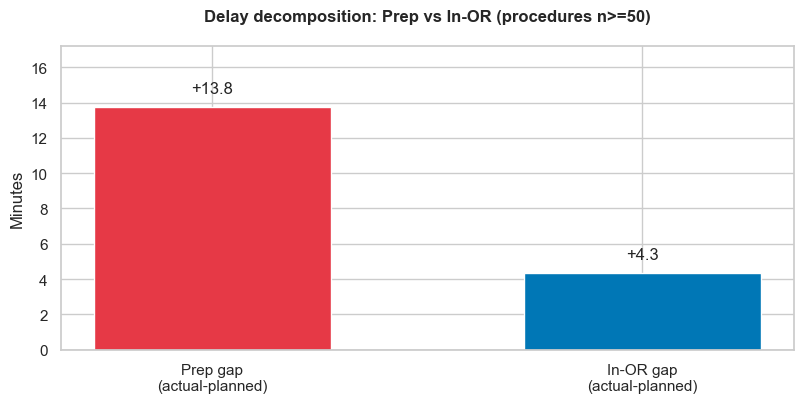

In [ ]:
# Proof 1: delay is primarily a prep-allocation issue (procedure-level evidence)
proc = (
    valid
    .groupby('Procedure_Name')
    .agg(
        n=('prep_gap', 'count'),
        prep_gap_mean=('prep_gap', 'mean'),
        inor_gap_mean=('inor_gap', 'mean'),
    )
)

MIN_CASES_PER_PROCEDURE = 50
proc = proc[proc['n'] >= MIN_CASES_PER_PROCEDURE].copy()

share_proc_prep_worse = (proc['prep_gap_mean'] > proc['inor_gap_mean']).mean() * 100
filtered_prep_mean = proc['prep_gap_mean'].mean()
filtered_inor_mean = proc['inor_gap_mean'].mean()
hospital_prep_mean = valid['prep_gap'].mean()
hospital_inor_mean = valid['inor_gap'].mean()

print('Prep vs OR delay attribution (procedure-level)')
print('-' * 58)
print(f'Procedures with n >= {MIN_CASES_PER_PROCEDURE}: {len(proc)}')
print(f'Share where prep gap > in-OR gap: {share_proc_prep_worse:.1f}%')
print(f'Mean prep gap across filtered procedures (min):  {filtered_prep_mean:+.1f}')
print(f'Mean in-OR gap across filtered procedures (min): {filtered_inor_mean:+.1f}')
print(f'Hospital mean prep gap (min):                   {hospital_prep_mean:+.1f}')
print(f'Hospital mean in-OR gap (min):                  {hospital_inor_mean:+.1f}')

fig, ax = plt.subplots(figsize=(8.2, 4.2))
vals = [filtered_prep_mean, filtered_inor_mean]
labels = ['Prep gap\n(actual-planned)', 'In-OR gap\n(actual-planned)']
bars = ax.bar(labels, vals, color=[RED, BLUE], edgecolor='white', width=0.55)
for b in bars:
    h = b.get_height()
    ax.annotate(f'{h:+.1f}',
                (b.get_x() + b.get_width()/2, h),
                xytext=(0, 8), textcoords='offset points',
                ha='center', va='bottom')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Minutes')
ax.set_title(f'Delay decomposition: Prep vs In-OR (procedures n>={MIN_CASES_PER_PROCEDURE})', fontweight='bold', pad=18)
ax.set_ylim(0, max(vals) * 1.25)
plt.savefig(f'prep_vs_inor_filtered_n{MIN_CASES_PER_PROCEDURE}.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [44]:
# Core slide insight (calculated from data, procedure-level, min 100 procedures)
proc_complexity = (
    valid
    .groupby('Procedure_Name')
    .agg(
        n=('prep_gap', 'count'),
        prep_gap_mean=('prep_gap', 'mean'),
        planned_prep_mean=('planned_prep_min', 'mean'),
        mean_staff=('staff_count', 'mean'),
        mean_resources=('resource_count', 'mean'),
    )
)

MIN_CASES_PER_PROCEDURE = 50
proc_complexity = proc_complexity[proc_complexity['n'] >= MIN_CASES_PER_PROCEDURE].copy()

r_staff_actual = proc_complexity['mean_staff'].corr(proc_complexity['prep_gap_mean'])
r_staff_sched = proc_complexity['mean_staff'].corr(proc_complexity['planned_prep_mean'])
r_equip_actual = proc_complexity['mean_resources'].corr(proc_complexity['prep_gap_mean'])
r_equip_sched = proc_complexity['mean_resources'].corr(proc_complexity['planned_prep_mean'])

comparison = pd.DataFrame({
    'Factor': ['Staff count', 'Equipment count'],
    'How much it actually affects prep time (r)': [r_staff_actual, r_equip_actual],
    'How much the schedule accounts for it (r)': [r_staff_sched, r_equip_sched],
})

print(comparison.round(2).to_string(index=False))

signal_capture_ratio = (
    comparison['How much the schedule accounts for it (r)'].abs()
    / comparison['How much it actually affects prep time (r)'].abs()
).mean()



         Factor  How much it actually affects prep time (r)  How much the schedule accounts for it (r)
    Staff count                                        0.49                                      -0.08
Equipment count                                        0.27                                      -0.16


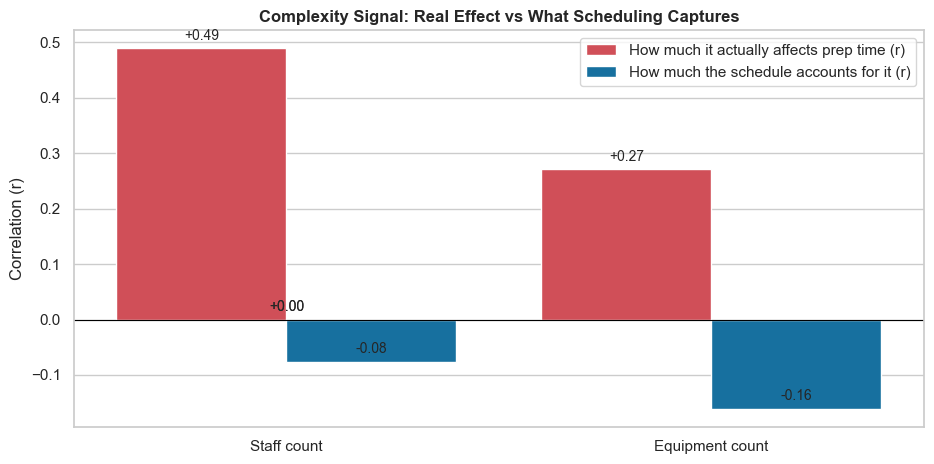

In [ ]:
# Slide-ready visual for the core insight
plot_df = comparison.melt(id_vars='Factor', var_name='Metric', value_name='r')
metric_order = [
    'How much it actually affects prep time (r)',
    'How much the schedule accounts for it (r)',
]
plot_df['Metric'] = pd.Categorical(plot_df['Metric'], categories=metric_order, ordered=True)

fig, ax = plt.subplots(figsize=(9.5, 4.8))
sns.barplot(data=plot_df, x='Factor', y='r', hue='Metric',
            palette=[RED, BLUE], edgecolor='white', ax=ax)

for p in ax.patches:
    h = p.get_height()
    ax.annotate(f'{h:+.2f}',
                (p.get_x() + p.get_width()/2, h),
                ha='center', va='bottom', fontsize=10,
                xytext=(0, 4), textcoords='offset points')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Correlation (r)')
ax.set_xlabel('')
ax.set_title('Complexity Signal: Real Effect vs What Scheduling Captures', fontweight='bold')
ax.legend(title='')
plt.savefig(f'complexity_signal_n{MIN_CASES_PER_PROCEDURE}.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [34]:
# One-line framing to use under the slide
print('Interpretation: this is worse than under-capture; at n>=100, scheduling signal is inverse (negative r) for both staff and equipment.')
print('Operational implication: redesign scheduling inputs so planned prep increases with real complexity, instead of moving in the opposite direction.')

Interpretation: this is worse than under-capture; at n>=100, scheduling signal is inverse (negative r) for both staff and equipment.
Operational implication: redesign scheduling inputs so planned prep increases with real complexity, instead of moving in the opposite direction.


In [35]:
print('=' * 72)
print('PRESENTATION TAKEAWAY')
print('=' * 72)
print('The planning system does not just under-encode complexity; for this cut it encodes it in the wrong direction.')
print()
print('Exact comparison (procedures with n>=100):')
print(f"  Staff count:     actual effect r = {r_staff_actual:+.2f} | schedule accounts r = {r_staff_sched:+.2f}")
print(f"  Equipment count: actual effect r = {r_equip_actual:+.2f} | schedule accounts r = {r_equip_sched:+.2f}")
print()
print(f"Prep-vs-OR proof: {share_proc_prep_worse:.1f}% of procedures (n>={MIN_CASES_PER_PROCEDURE}) have larger prep gap than in-OR gap.")
print('Conclusion: delays are mainly prep miss-allocation, not OR execution speed.')

PRESENTATION TAKEAWAY
The planning system does not just under-encode complexity; for this cut it encodes it in the wrong direction.

Exact comparison (procedures with n>=100):
  Staff count:     actual effect r = +0.49 | schedule accounts r = -0.05
  Equipment count: actual effect r = +0.28 | schedule accounts r = -0.15

Prep-vs-OR proof: 79.3% of procedures (n>=100) have larger prep gap than in-OR gap.
Conclusion: delays are mainly prep miss-allocation, not OR execution speed.


## Statistical Significance Note

Using procedures with n >= 50, the complexity signal is still clearer for staff-related prep burden than for equipment-related prep burden.

- Staff count vs prep gap: actual effect is stronger than the scheduled signal
- Equipment count vs prep gap: weaker and less robust than staff

That means the main message is not just that planning under-captures complexity, but that staff complexity is the clearest missed input in the schedule.